<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/05_stan_radon.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(stan-multilevel-notebook)=
# Regressione multilivello con Stan


I dati e i modelli per questo notebook sono presi dal capitolo 12 del libro "Data Analysis Using Regression and Multilevel/Hierarchical Models" di Andrew Gelman e Jennifer Hill, Cambridge Press, 2007. In questo capitolo viene utilizzato un modello di regressione multinivel per analizzare i dati provenienti da un sondaggio nazionale sui livelli di radon nelle case negli Stati Uniti effettuato dall'EPA nei primi anni '90.

L'obiettivo dello studio sul radon è fornire stime ragionevoli dei livelli di radon nelle case in ciascuna delle circa 3000 contee negli Stati Uniti. Il gas radon è un prodotto del lento decadimento dell'uranio in piombo. A causa delle differenze geologiche locali, il livello di esposizione al gas radon varia da luogo a luogo. Una fonte comune è rappresentata dai minerali contenenti uranio nel terreno e quindi si accumula in aree sotterranee come le cantine.

In [12]:
import os
import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel
import arviz as az

# plotting libs
import matplotlib.pyplot as plt

# suppress plotnine warnings
import warnings
warnings.filterwarnings('ignore')

In [63]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

# Imposta la precisione globale a 2 cifre decimali
pd.set_option('display.precision', 2)

In [17]:
mn_radon = pd.read_csv(os.path.join('../data','radon.csv'))
print(f'number of houses: {len(mn_radon)}')
mn_radon.head(7)

number of houses: 919


,floor,county,log_radon,log_uranium
0,1,AITKIN,0.832909,-0.689048
1,0,AITKIN,0.832909,-0.689048
2,0,AITKIN,1.098612,-0.689048
3,0,AITKIN,0.095310,-0.689048
4,0,ANOKA,1.163151,-0.847313
5,0,ANOKA,0.955511,-0.847313
6,0,ANOKA,0.470004,-0.847313


Per questo caso di studio, il modello di base è un modello di regressione lineare regolare (non multilivello), vedi Appendice A, dove l'esito $y$ è il livello di radon logaritmico domestico e il predittore $x$ è il piano sul quale è stata effettuata la misurazione. Consideriamo due possibili modelli: raggruppamento completo (complete pooling) e nessun raggruppamento (no-pooling).

Il modello di raggruppamento completo stima un unico termine di intercetta per la regressione:
$$ \text{log\_radon}_i = \alpha + \beta \cdot \text{floor}_i + \epsilon_i. $$

Il modello senza raggruppamento stima un termine di intercetta per contea. Il termine di intercetta $\alpha$ è un vettore di dimensione $J$, il numero di contee:
$$ \text{log\_radon}_i = \alpha_{j[i]} + \beta \cdot \text{floor}_i + \epsilon_i $$
dove $j = 1 \ldots 85$.

Gelman e Hill usano la notazione $\alpha_{j[i]}$ per denotare l'elemento di $j$ corrispondente all'osservazione $i$, sostenendo che questa notazione riflette meglio la struttura dei dati.

Poiché i piani sono codificati come $\text{floor\_basement} = 0$, $\text{floor\_ground} = 1$, per le misurazioni al piano interrato, l'esito osservato $\text{log\_radon}$ è semplicemente il termine di intercetta più l'errore di misurazione.

## Modello di raggruppamento completo

In [7]:
stan_file = os.path.join('stan', 'bivariate_linreg_model.stan')
with open(stan_file, 'r') as f:
    print(f.read())

data {
  int<lower=1> N;
  vector[N] x;
  vector[N] y;
}
parameters {
  real alpha;
  real beta;
  real<lower=0> sigma;
}
model {
  y ~ normal(alpha + beta * x, sigma);
  alpha ~ normal(0, 2.5);
  beta ~ normal(0, 2.5);
  sigma ~ normal(0, 2.5);
}
generated quantities {
  array[N] real y_rep = normal_rng(alpha + beta * x, sigma);
}



In [8]:
model = CmdStanModel(stan_file=stan_file)
print(model)

CmdStanModel: name=bivariate_linreg_model
	 stan_file=/Users/corradocaudek/_repositories/ds4p/chapter_5/stan/bivariate_linreg_model.stan
	 exe_file=/Users/corradocaudek/_repositories/ds4p/chapter_5/stan/bivariate_linreg_model
	 compiler_options=stanc_options={}, cpp_options={}


In [9]:
radon_data = {"N": len(mn_radon), 
              "x": mn_radon.floor.astype(float), 
              "y": mn_radon.log_radon
            }

In [ ]:
complete_pooling_fit = model.sample(data=radon_data)

In [13]:
az.summary(complete_pooling_fit, var_names=(["alpha", "beta", "sigma"]), hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.363,0.028,1.305,1.417,0.001,0.000,2992.0,2434.0,1.0
beta,-0.586,0.070,-0.722,-0.448,0.001,0.001,2884.0,2524.0,1.0
sigma,0.791,0.019,0.753,0.826,0.000,0.000,3143.0,2604.0,1.0


## Modello di raggruppamento parziale

In [14]:
stan_file = os.path.join('stan', 'radon_h_model.stan')
with open(stan_file, 'r') as f:
    print(f.read())

data {
  int<lower=1> N;  // observations
  int<lower=1> J;  // counties
  array[N] int<lower=1, upper=J> county;
  vector[N] x;
  vector[N] y;
}
parameters {
  real mu_alpha;
  real<lower=0> sigma_alpha;
  vector<offset=mu_alpha, multiplier=sigma_alpha>[J] alpha;  // non-centered parameterization
  real beta;
  real<lower=0> sigma;
}
model {
  y ~ normal(alpha[county] + beta * x, sigma);  
  alpha ~ normal(mu_alpha, sigma_alpha); // partial-pooling
  beta ~ normal(0, 10);
  sigma ~ normal(0, 10);
  mu_alpha ~ normal(0, 10);
  sigma_alpha ~ normal(0, 10);
}
generated quantities {
  array[N] real y_rep = normal_rng(alpha[county] + beta * x, sigma);
}



In [15]:
model = CmdStanModel(stan_file=stan_file)
print(model)

11:53:54 - cmdstanpy - INFO - compiling stan file /Users/corradocaudek/_repositories/ds4p/chapter_5/stan/radon_h_model.stan to exe file /Users/corradocaudek/_repositories/ds4p/chapter_5/stan/radon_h_model
11:54:07 - cmdstanpy - INFO - compiled model executable: /Users/corradocaudek/_repositories/ds4p/chapter_5/stan/radon_h_model


CmdStanModel: name=radon_h_model
	 stan_file=/Users/corradocaudek/_repositories/ds4p/chapter_5/stan/radon_h_model.stan
	 exe_file=/Users/corradocaudek/_repositories/ds4p/chapter_5/stan/radon_h_model
	 compiler_options=stanc_options={}, cpp_options={}


In [53]:
mn_radon['county_id'] = pd.factorize(mn_radon['county'])[0] + 1
mn_radon.county_id

0       1
1       1
2       1
3       1
4       2
       ..
914    84
915    84
916    84
917    85
918    85
Name: county_id, Length: 919, dtype: int64

In [54]:
np.unique(mn_radon["county_id"]) 

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85])

In [59]:
radon2_data = {
    "N": mn_radon.shape[0], 
    "x": mn_radon.floor.astype(float), 
    "y": mn_radon.log_radon,
    "J": len(pd.unique(mn_radon['county'])), 
    "county" : mn_radon["county_id"]
}

In [ ]:
partial_pooling_fit = model.sample(data=radon2_data)

In [64]:
az.summary(partial_pooling_fit, var_names=(["alpha", "beta", "sigma"]), hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],1.26,0.22,0.78,1.64,2.60e-02,1.90e-02,106.0,1319.0,1.20
alpha[1],1.08,0.18,0.81,1.40,8.20e-02,6.30e-02,7.0,34.0,1.53
alpha[2],1.47,0.22,1.07,1.97,3.00e-02,2.30e-02,67.0,1797.0,1.14
alpha[3],1.49,0.20,1.12,1.93,3.90e-02,2.90e-02,30.0,2011.0,1.08
alpha[4],1.44,0.21,1.05,1.90,2.20e-02,1.80e-02,117.0,1658.0,1.20
...,...,...,...,...,...,...,...,...,...
alpha[82],1.54,0.19,1.26,1.91,5.40e-02,3.90e-02,14.0,1817.0,1.20
alpha[83],1.55,0.19,1.29,1.93,5.60e-02,4.10e-02,12.0,1758.0,1.23
alpha[84],1.40,0.24,0.91,1.90,3.00e-03,3.00e-03,5612.0,1947.0,1.27
beta,-0.64,0.08,-0.78,-0.49,1.80e-02,1.30e-02,19.0,105.0,1.15


array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

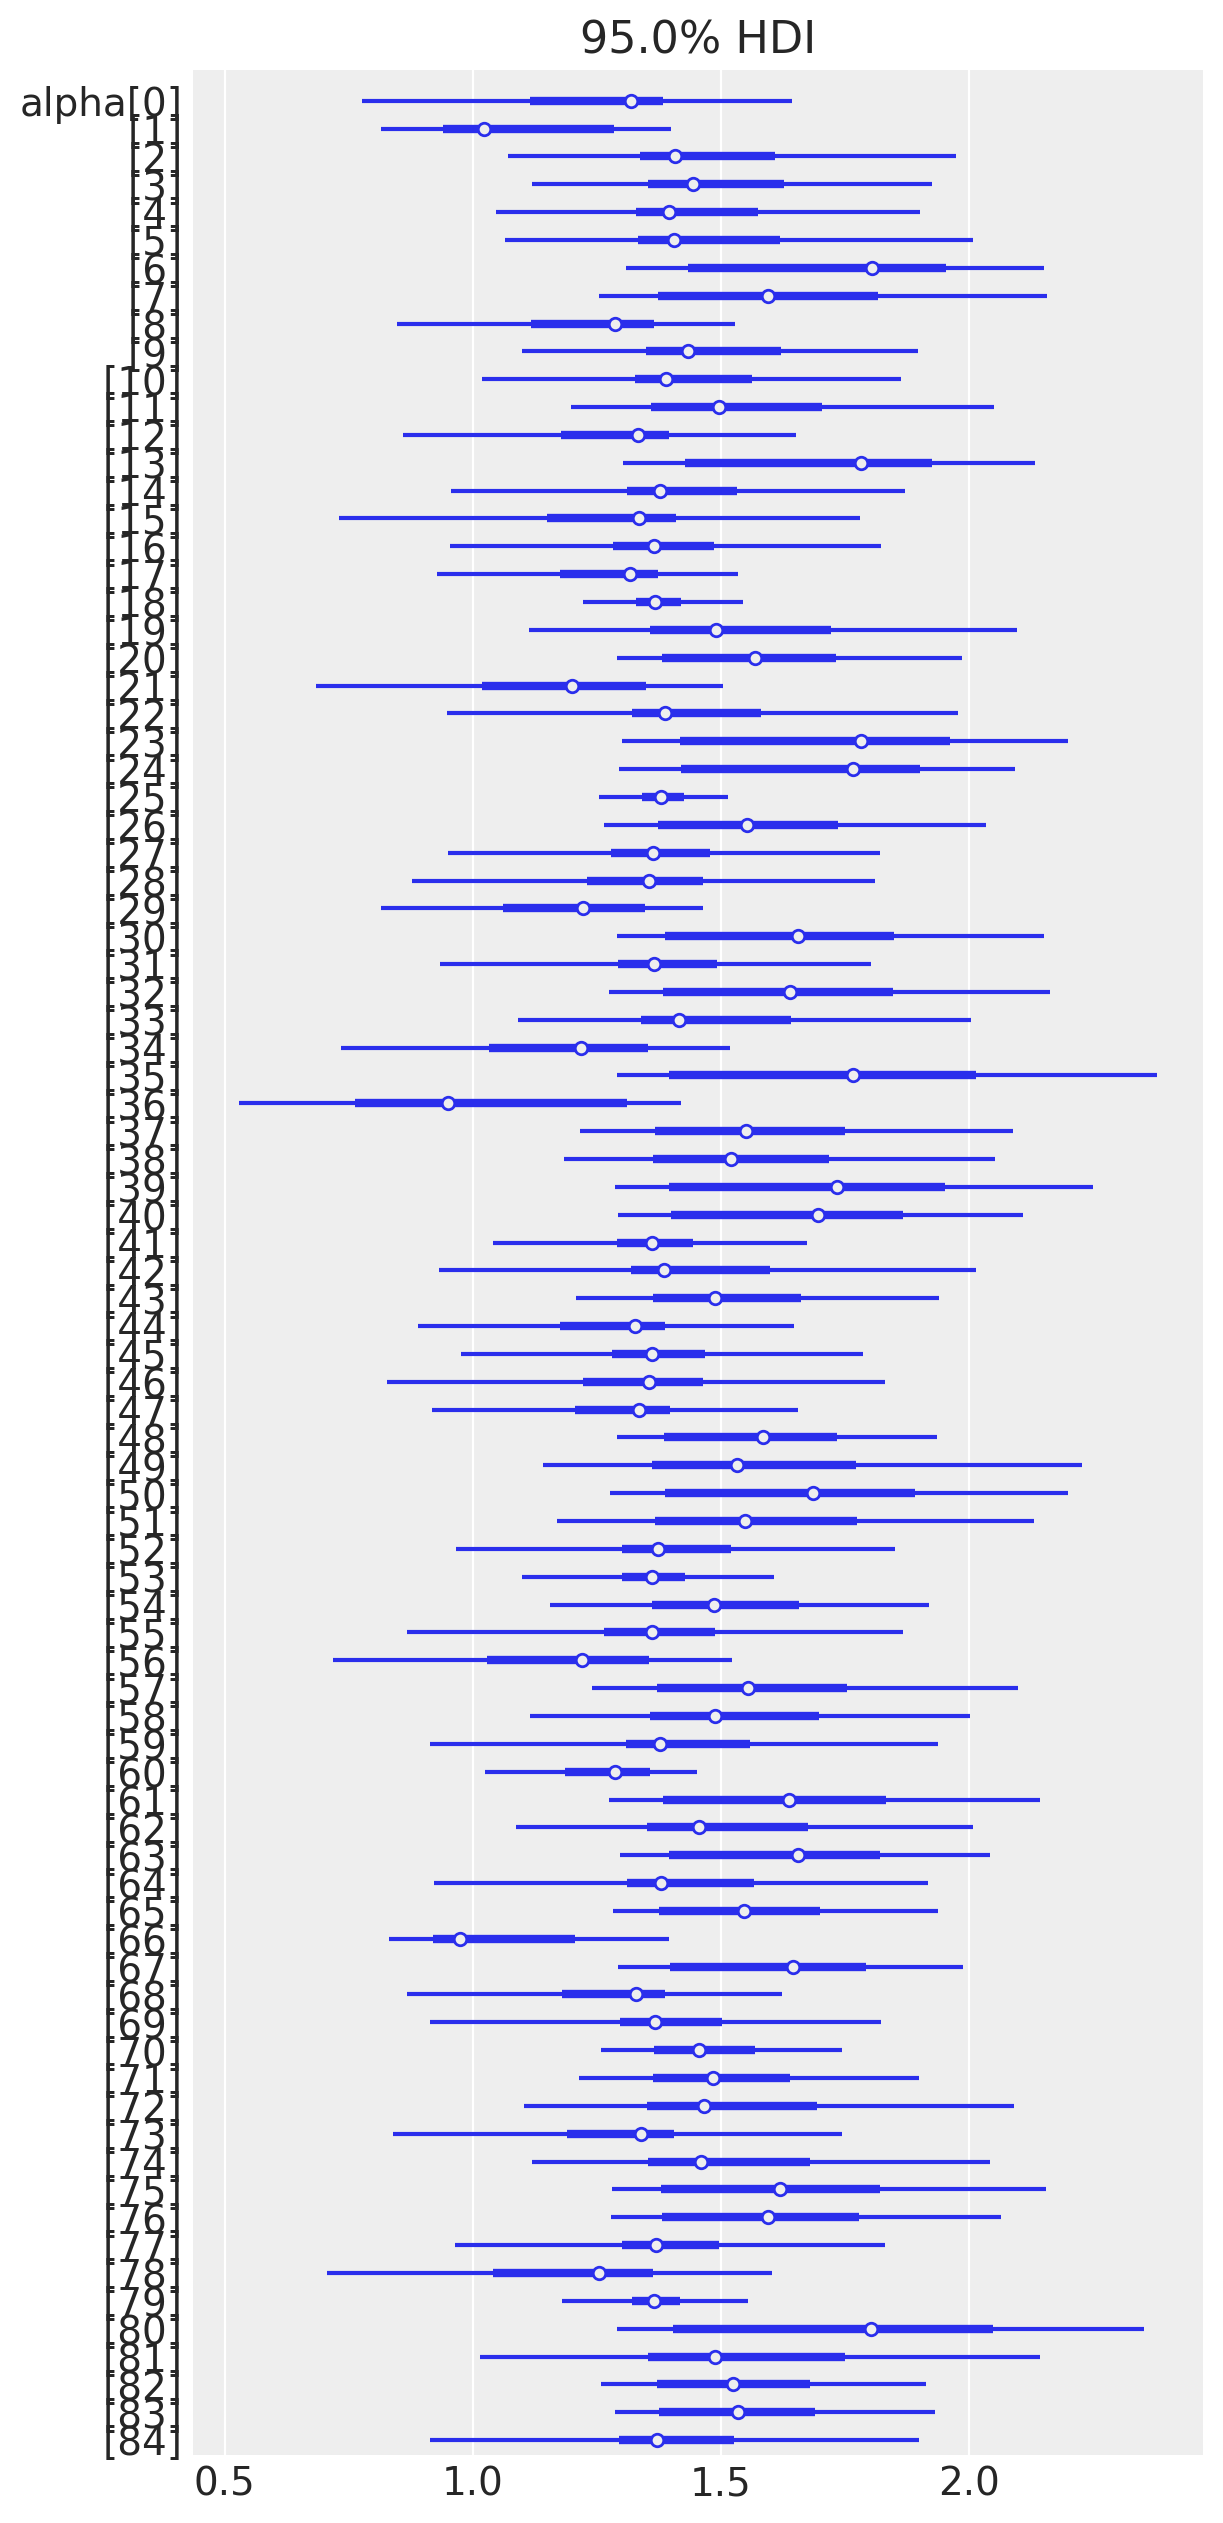

In [65]:
_ = az.plot_forest(partial_pooling_fit, var_names=["alpha"], hdi_prob=0.95, combined=True)

In [ ]:
az.plot_posterior(partial_pooling_fit, var_names=["alpha"], hdi_prob=0.95)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

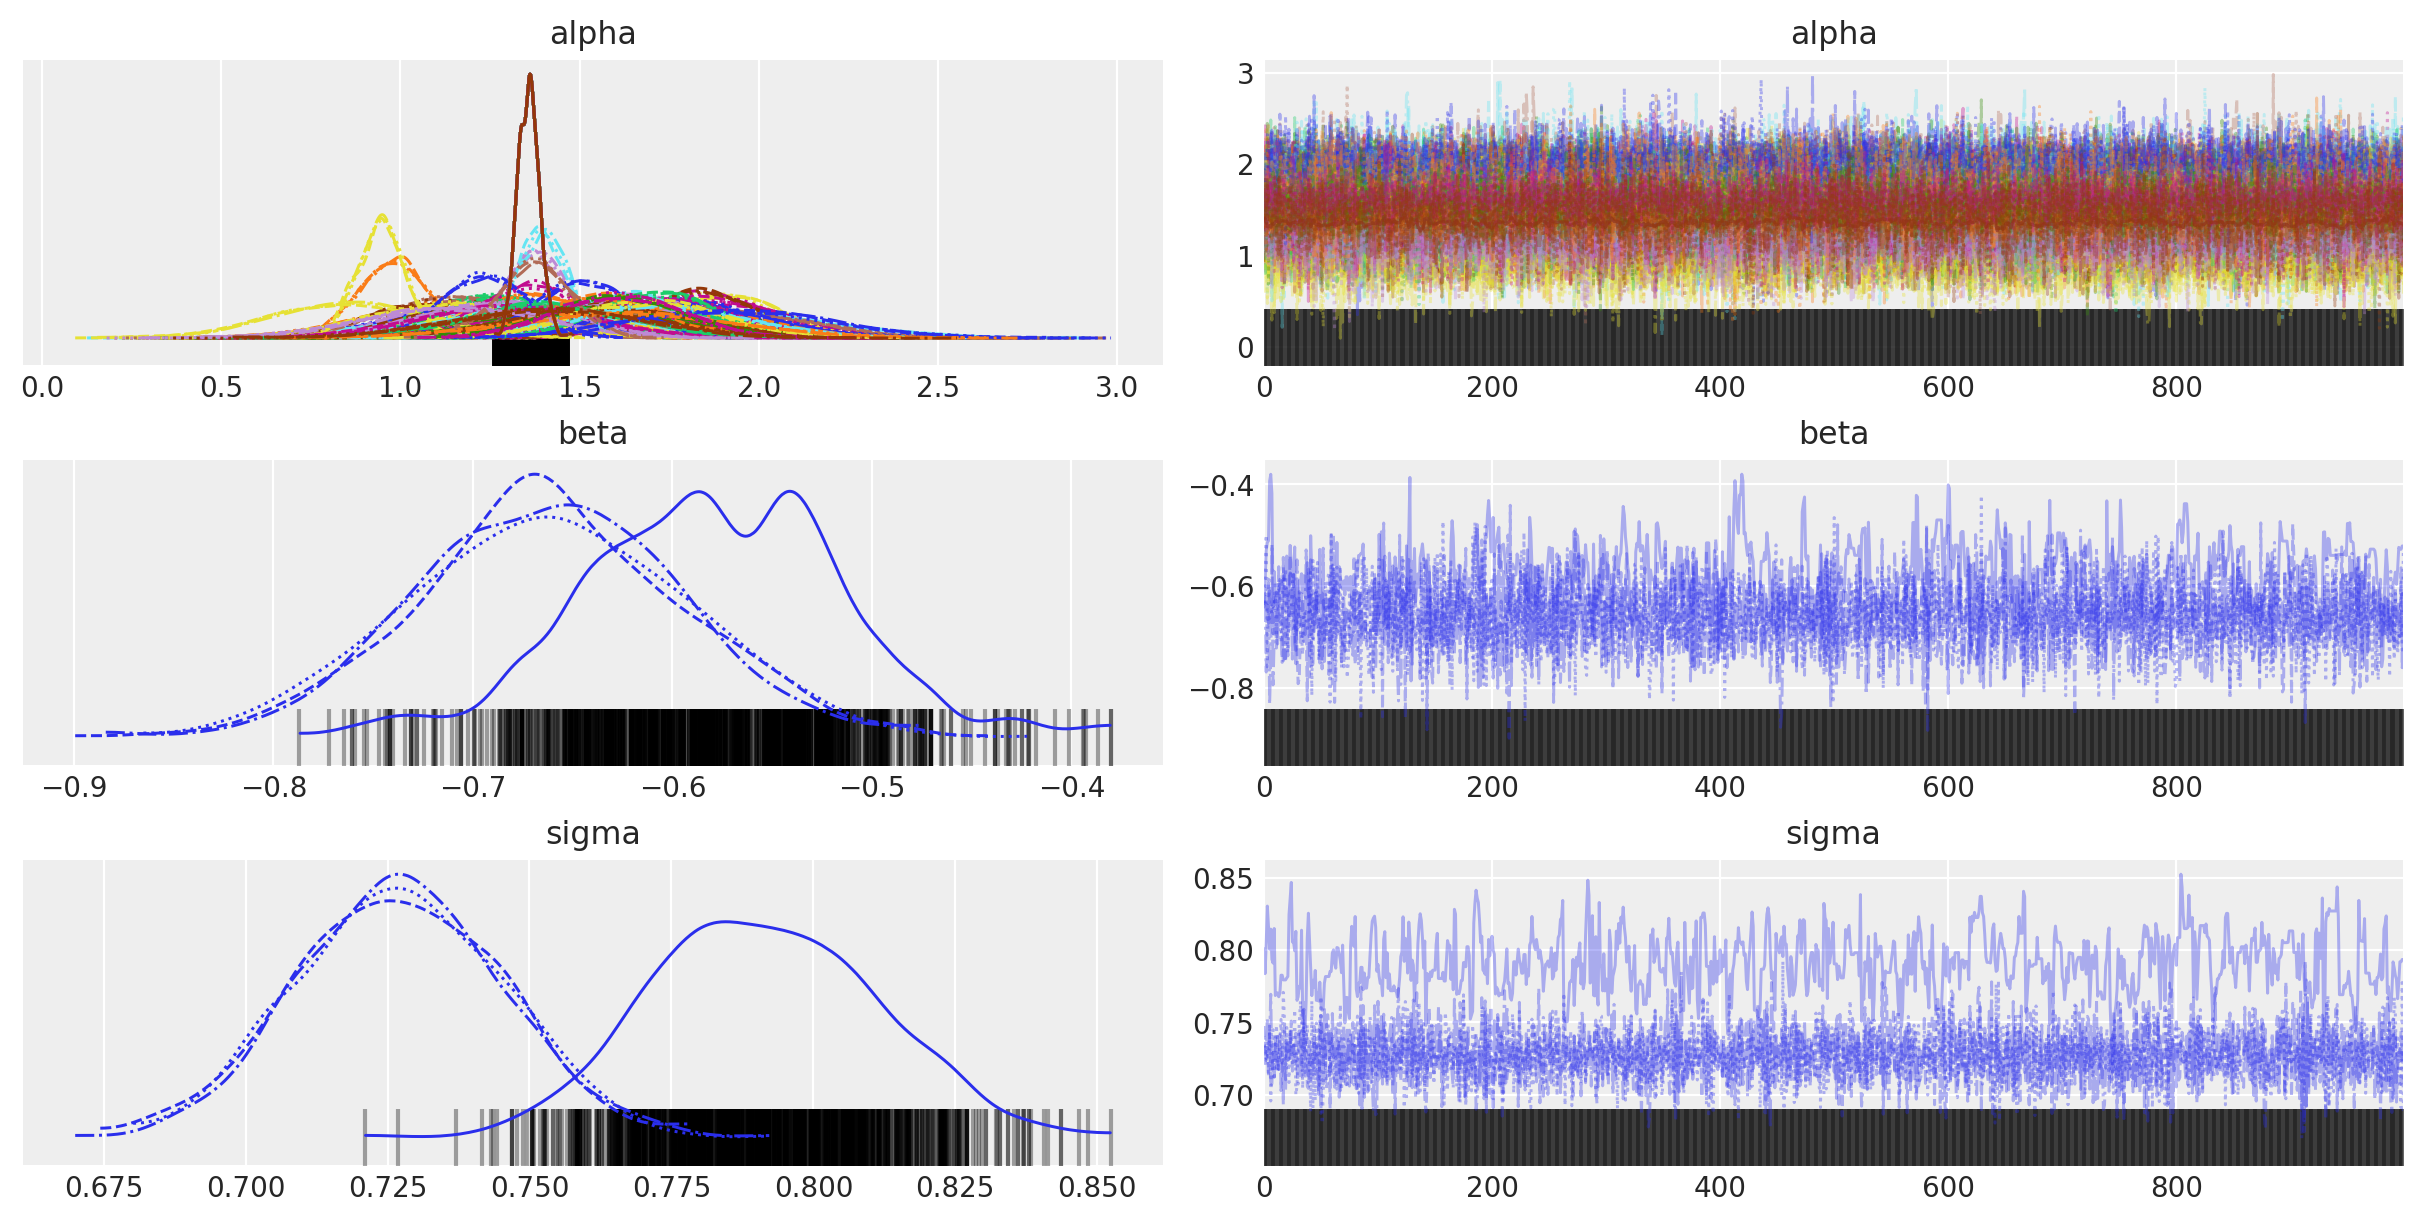

In [67]:
az.plot_trace(partial_pooling_fit, var_names=["alpha", "beta", "sigma"])

Nel modello di ragruppamento parziale, `alpha` rappresenta un insieme di intercette casuali per le `J` contee. Questo approccio è tipico dei modelli gerarchici o multi-livello, dove si assume che i dati siano raggruppati in modo naturale (in questo caso, per contea). L'uso di intercette casuali permette al modello di considerare la variabilità tra questi gruppi, offrendo una flessibilità maggiore rispetto a un modello con un'unica intercetta fissa per tutti i dati. Ecco un'interpretazione più dettagliata del parametro `alpha` e dei parametri correlati:

### Interpretazione di `alpha`
- **`alpha[j]`:** Ciascun elemento di `alpha` corrisponde a un effetto specifico della contea `j` sull'intercetta del modello. In altre parole, `alpha[j]` regola il valore base di `y` per la contea `j`, prima di considerare l'effetto della variabile predittiva `x`. Questo permette al modello di adattarsi meglio ai dati, riconoscendo che diverse contee possono avere livelli di base diversi della variabile risposta `y`.

### `mu_alpha` e `sigma_alpha`
- **`mu_alpha`:** La media globale delle intercette casuali `alpha`. Questo parametro rappresenta l'effetto medio di base attraverso tutte le contee, assumendo che `x` sia zero (se `x` è centrato o standardizzato, `mu_alpha` rappresenta l'effetto medio quando `x` è al suo valore medio).
- **`sigma_alpha`:** La deviazione standard delle intercette casuali `alpha`, che misura la variabilità degli effetti di base delle contee intorno alla loro media globale `mu_alpha`. Un valore maggiore di `sigma_alpha` indica una maggiore variabilità tra le contee, mentre un valore vicino a zero suggerisce che le intercette delle diverse contee sono simili tra loro.

### Interpretazione in Contesto
L'interpretazione di `alpha` (e dei parametri correlati) dipende fortemente dal contesto dello studio. Nel caso presente, `y` è il logaritmo della concentrazione di radon e `x` è un indicatore del livello del suolo di una casa (0 per il seminterrato, 1 per il primo piano). Allora `alpha[j]` rappresenta la concentrazione media di radon a livello del suolo per la contea `j`, mentre `beta` quantifica l'effetto aggiuntivo di avere la casa al primo piano rispetto al seminterrato, controllando per gli effetti di base specifici della contea.

### Vantaggi dell'Approccio Gerarchico
L'uso di intercette casuali e la parametrizzazione non centrata (tramite `offset` e `multiplier`) aumenta l'efficienza computazionale e la convergenza del modello nei casi in cui la gerarchia dei dati è importante. Il "partial pooling" (pooling parziale) permesso da `sigma_alpha` offre un equilibrio tra il "complete pooling" (dove si ignora la struttura di raggruppamento dei dati) e il "no pooling" (dove si adatta un modello separato per ogni gruppo), permettendo di "prestare forza" tra i gruppi e migliorare le stime, soprattutto quando alcuni gruppi hanno poche osservazioni.

## Parametrizzazione non centrata

La parametrizzazione non centrata è una tecnica utile per migliorare la convergenza e l'efficienza di campionamento in modelli gerarchici o multilivello, specialmente quando si utilizza il campionamento Hamiltoniano Monte Carlo (HMC) o algoritmi simili. Questo approccio si rivela particolarmente efficace nei casi in cui la struttura gerarchica del modello introduce dipendenze complesse tra i parametri, potenzialmente portando a problemi di convergenza o a campionamenti inefficaci.

Nel contesto del modello Stan presente, la parametrizzazione non centrata viene applicata al termine `alpha`, che rappresenta gli effetti casuali (o le intercette) per ogni contea. Invece di stimare direttamente `alpha` come un effetto casuale centrato attorno a `mu_alpha` con deviazione standard `sigma_alpha` (approccio centrato), si procede diversamente:

1. Si definisce `alpha` utilizzando una parametrizzazione offset-multiplier, dove `mu_alpha` è l'offset e `sigma_alpha` è il moltiplicatore. Questo significa che `alpha` non è più stimato direttamente come un valore centrato attorno a `mu_alpha`, ma come una deviazione in unità standard dalla media, che poi viene scalata da `sigma_alpha` e traslata da `mu_alpha`.

2. Questo si traduce in una definizione di `alpha` che inizia da una distribuzione normale standard (media = 0, deviazione standard = 1) che viene poi trasformata applicando la scala `sigma_alpha` e traslando di `mu_alpha`.

### Esempio Numerico

Supponiamo di avere due contee (`J=2`) con i seguenti parametri stimati dal modello:

- `mu_alpha = 1.5` (media globale delle intercette per le contee)
- `sigma_alpha = 0.5` (deviazione standard delle intercette tra le contee)
- Per la contea 1, un valore stimato non centrato di `alpha` è `0.2`
- Per la contea 2, un valore stimato non centrato di `alpha` è `-0.3`

Applicando la trasformazione offset-multiplier, calcoliamo le intercette per ogni contea:

- Intercetta contea 1: `1.5 + 0.2 * 0.5 = 1.6`
- Intercetta contea 2: `1.5 + (-0.3) * 0.5 = 1.35`

Questi valori di `alpha` trasformati vengono poi utilizzati nel modello per prevedere `y`, tenendo conto degli effetti specifici della contea e dell'effetto del predittore `x` attraverso il coefficiente `beta`.

### Vantaggi

La parametrizzazione non centrata aiuta a ridurre la correlazione tra `mu_alpha`, `sigma_alpha` e gli effetti casuali `alpha`, migliorando la geometria del problema di campionamento per gli algoritmi HMC. Ciò porta spesso a una maggiore efficienza di campionamento e a una convergenza più rapida, soprattutto in modelli complessi con una forte struttura gerarchica.